In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.basemap import Basemap
from matplotlib.colors import ListedColormap
import glasbey
import netCDF4
import matplotlib

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config

# Longhurst provinces

Flanders Marine Institute (2009). Longhurst Provinces. Available online at https://www.marineregions.org/. Consulted on 2023-11-28.

https://www.marineregions.org/sources.php#longhurst

In [2]:
longhurst = gpd.read_file("../../data/province_shapes/longhurst_v4_2010/Longhurst_world_v4_2010.shp")

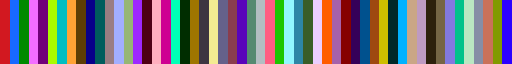

In [3]:
# Define color map and ranges
unique_labels = np.sort(longhurst.ProvCode.unique())

colors = glasbey.create_palette(palette_size=len(unique_labels))
cm = ListedColormap(colors)  

cm

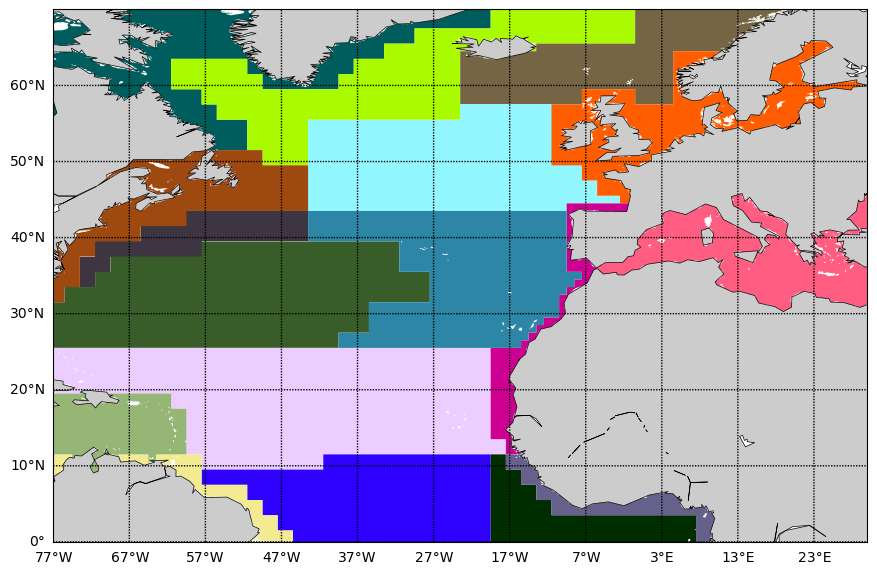

In [4]:
# Defining our area of interest
lat_min = 0
lat_max = 70

lon_min = -77
lon_max = 30

# Plot settings
factor = 12
mymap = Basemap(llcrnrlon=lon_min, llcrnrlat=lat_min, urcrnrlon=lon_max, urcrnrlat=lat_max)
plt.rcParams["figure.figsize"] = ((lon_max - lon_min)/factor, (lat_max - lat_min)/factor)

# Plot
longhurst.plot("ProvCode", cmap=cm, vmin=0, vmax=len(unique_labels))
mymap.drawcoastlines(linewidth=0.5)
mymap.fillcontinents()
mymap.drawparallels(np.arange(int(lat_min),int(lat_max), 10),labels=[1,0,0,0])
mymap.drawmeridians(np.arange(int(lon_min),int(lon_max), 10),labels=[0,0,0,1])
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.tight_layout()
# plt.savefig(f"{config.output_dir_plots}longhurst_surface.png")
plt.savefig(f"{config.output_dir_plots_high_res}longhurst_surface.png", dpi=1000)
plt.show()

<AxesSubplot: >

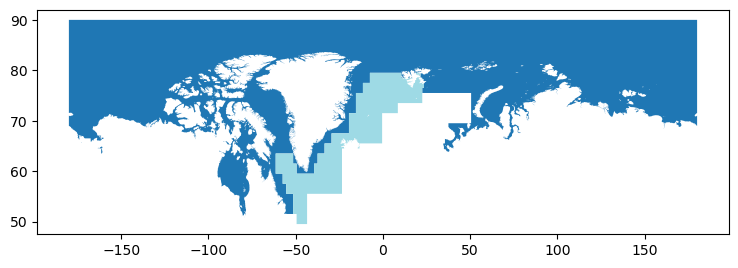

In [5]:
longhurst[longhurst.ProvCode.isin(["ARCT",  "BPLR",# "SARC", 
                                   # "NADR", "GFST", "NASW", 
                                   # "CARB", "NATR",
                                   # "WTRA", "ETRA", "NWCS", "MEDI", "NASE", 
                                  ])].plot(cmap="tab20")

# Overlay our regions with Longhurst's provinces

In [6]:
# Load our regions
my_regions = netCDF4.Dataset(f"{config.output_dir}cluster_set.nc")

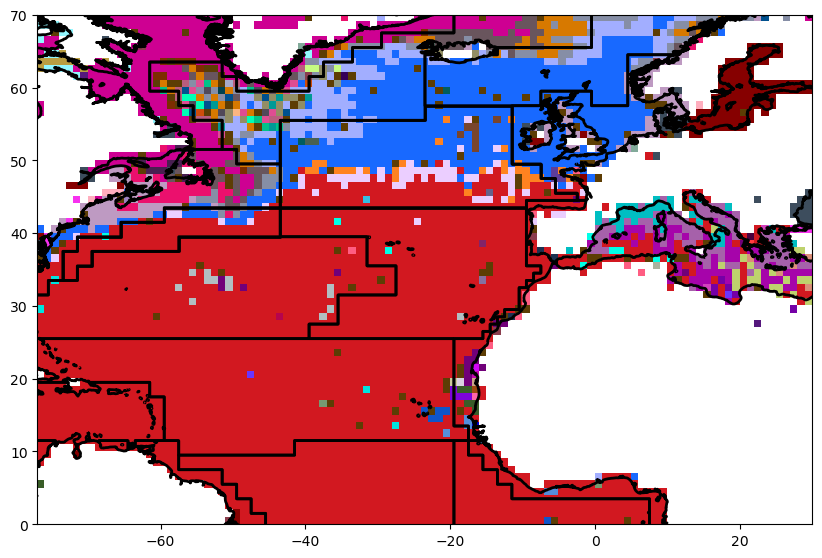

In [8]:
# Plot our area of interest
depth = 0.0
hex_colors = my_regions["color"][0, :, :] 
rgb = np.array([[matplotlib.colors.to_rgb(color) if type(color) == str and color is not None and color != "" else np.array([1, 1, 1]) for color in row] for row in hex_colors])
    
# Defining out area
lat_min = 0
lat_max = 70

lon_min = -77
lon_max = 30

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
plt.imshow(rgb, extent=[lon_min, lon_max, lat_min, lat_max], origin='lower')
longhurst.plot("ProvCode", ax=ax, edgecolor="black", facecolor="none", linewidth=2)  

ax.set_xlim(lon_min, lon_max)
ax.set_ylim(lat_min, lat_max)

plt.show()